In [11]:
import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)


In [12]:
TICKER = "AAPL"
PERIOD = "10y"
INTERVAL = "1d"

# Candidate features available for modeling (centralized here)
FEATURES = [
    "rsi_14",
    "macd_hist_12_26_9",
    "bb_bandwidth_20_2",
    "adx_14",
    "obv",
    "adj_close_smooth",
    "ema_20",
    "atr_14",
    "volume"
]
    
TARGET = "target_close_1d"


## Chapter 2: Dataset & Preprocessing

### Dataset Description
- **Source:** Yahoo Finance via `yfinance`.
- **Asset:** `AAPL` (Apple Inc.).
- **Sampling:** daily bars (`interval = 1d`) over the last ~10 years (`period = 10y`).
- **Raw fields used:** `High`, `Low`, `Close`, `Adj Close`, `Volume` (time indexed by trading date).

In [13]:
df = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=False,
    actions=False,
    progress=False,
)
df.head(5)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2016-04-18,24.342121,26.870001,27.237499,26.735001,27.222500,243286000
2016-04-19,24.213024,26.727501,27.000000,26.557501,26.969999,129539600
2016-04-20,24.262852,26.782499,27.022499,26.514999,26.660000,122444000
2016-04-21,24.000132,26.492500,26.732500,26.379999,26.732500,126210000
2016-04-22,23.934462,26.420000,26.620001,26.155001,26.252501,134732400


### Prepare Clean 1D Series and Apply Smoothing

This section standardizes the OHLCV inputs into clean 1D numeric series, then applies exponential smoothing to reduce noise before feature engineering.

**Justification**: 

Exponential smoothing gives more weight to recent data while still considering past trends, which makes indicator values steadier and less affected by unusual one-day spikes.

In [14]:
def to_series_1d(x, name: str) -> pd.Series:
    """Coerce 1-col DataFrame/Series into a clean numeric Series."""
    x = x.iloc[:, 0]
    s = pd.Series(x, index=x.index, name=name)
    return pd.to_numeric(s, errors="coerce")


def exp_smooth(series: pd.Series, alpha: float = 0.2) -> pd.Series:
    return series.ewm(alpha=alpha, adjust=False).mean()

In [15]:
ALPHA = 0.3

raw_close = to_series_1d(df["Close"], "Close")
raw_adj_close = to_series_1d(df["Adj Close"], "Adj Close")
raw_high = to_series_1d(df["High"], "High")
raw_low = to_series_1d(df["Low"], "Low")
raw_volume = to_series_1d(df["Volume"], "Volume")

s_adj_close = exp_smooth(raw_adj_close, ALPHA)
s_high = exp_smooth(raw_high, ALPHA)
s_low = exp_smooth(raw_low, ALPHA)
s_volume = exp_smooth(raw_volume, ALPHA)

#### Compare Raw vs Smoothed Price

This section visualizes the original close price against the smoothed adjusted close series to show how smoothing reduces short-term noise while preserving the broader trend.

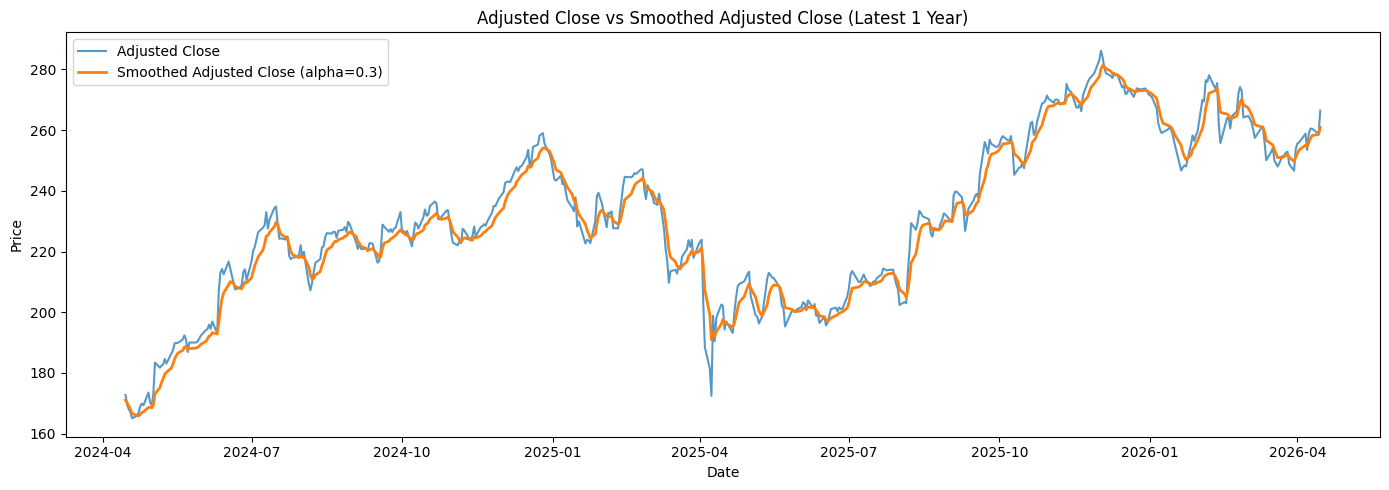

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

# Keep only the most recent 2 years
end_date = raw_close.index.max()
start_date = end_date - pd.DateOffset(years=2)

raw_close_1y = raw_close.loc[start_date:end_date]
s_adj_close_1y = s_adj_close.loc[start_date:end_date]

ax.plot(raw_close_1y.index, raw_close_1y, label="Adjusted Close", alpha=0.75)
ax.plot(
    s_adj_close_1y.index,
    s_adj_close_1y,
    label=f"Smoothed Adjusted Close (alpha={ALPHA})",
    linewidth=2
)

ax.set_title("Adjusted Close vs Smoothed Adjusted Close (Latest 1 Year)")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()


### Technical Indicator Overview

These indicators convert raw OHLCV into structured market-state signals. Before computing indicators, it helps to group them by category and purpose:

**Feature Variables**:

| Feature | Category | What It Measures | Why It Is Included |
|---|---|---|---|
| `rsi_14` | Momentum | Relative strength of recent gains vs losses over 14 days | Helps capture overbought/oversold conditions and short-term reversal pressure |
| `macd_hist_12_26_9` | Momentum | Distance between MACD and signal line | Captures changes in momentum and potential trend turning points |
| `adx_14` | Trend | Strength of trend over 14 days (regardless of direction) | Helps distinguish trending regimes from sideways/noisy regimes |
| `ema_20` | Trend | 20-day exponential moving average | Emphasizes recent prices and provides a responsive trend baseline |
| `obv` | Volatility | Cumulative volume flow aligned with price direction | Adds buying/selling pressure information beyond price alone |
| `bb_bandwidth_20_2` | Volatility | Width of Bollinger Bands (20-day, 2 std) | Represents volatility expansion/contraction and shifting market uncertainty |
| `atr_14` | Volatility | Average true range over 14 days | Captures typical trading range and short-term risk magnitude |
| `volume` | Volatility | Shares traded per day | Reflects participation/liquidity and supports move-confirmation signals |
| `adj_close_smooth` | Price | Exponentially smoothed adjusted close series | Reduces day-to-day noise while preserving medium-term price structure |

**Target variable:**  

The prediction target is **next-day Adjusted Close** (`target_close_1d`), not raw Close. This is preferred because **Adjusted Close accounts for corporate actions such as stock splits** (and dividends), making the historical series more consistent over time and avoids artificial jumps from stock-split events.

In [17]:
feat = pd.DataFrame(index=df.index)

# Keep core price references (ensure 1D numeric series)
feat["Adj Close"] = raw_adj_close
feat["adj_close_smooth"] = s_adj_close
feat["target_ret_1d_pct"] = (raw_adj_close.pct_change().shift(-1) * 100)

feat["volume"] = s_volume

# Indicator engineering
feat["rsi_14"] = ta.rsi(s_adj_close, length=14)

macd_df = ta.macd(close=s_adj_close, fast=12, slow=26, signal=9)
feat["macd_hist_12_26_9"] = macd_df["MACDh_12_26_9"]

adx_df = ta.adx(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["adx_14"] = adx_df["ADX_14"]

feat["atr_14"] = ta.atr(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["obv"] = ta.obv(close=s_adj_close, volume=s_volume)
feat["sma_10"] = ta.sma(s_adj_close, length=10)
feat["ema_20"] = ta.ema(s_adj_close, length=20)

bb_df = ta.bbands(s_adj_close, length=20, std=2)
feat["bb_bandwidth_20_2"] = bb_df["BBB_20_2"]

# Targets available for training
feat["target_close_1d"] = raw_adj_close.shift(-1)

### Missing-Value Row Removal (`dropna`)

This section removes any rows in that still contain missing (`NaN`) values to ensure a clean dataset for modeling.

In [18]:
rows_before = len(feat)
feat = feat.dropna().copy()
rows_after = len(feat)

summary = pd.DataFrame({
    "metric": ["rows_before_dropna", "rows_after_dropna", "rows_removed"],
    "value": [rows_before, rows_after, rows_before - rows_after],
})

print("Final modeling shape:", feat.shape)
display(summary)

missing_tbl = pd.DataFrame({
    "missing_count": feat.isna().sum(),
}).sort_values("missing_count", ascending=False)
missing_tbl

Final modeling shape: (2479, 13)


,metric,value
0,rows_before_dropna,2513
1,rows_after_dropna,2479
2,rows_removed,34


,missing_count
Adj Close,0
adj_close_smooth,0
target_ret_1d_pct,0
volume,0
rsi_14,0
macd_hist_12_26_9,0
adx_14,0
atr_14,0
obv,0
sma_10,0


### Save Processed Outputs

This section saves the cleaned feature dataset and writes a modeling configuration file so the same inputs can be reused consistently in later training and evaluation steps.

In [19]:
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared dataset path consumed by Notebook 02 and Notebook 03
FEATURE_PATH_CSV = OUT_DIR / "aapl_features_smoothed.csv"

# Single source-of-truth modeling config for downstream notebooks
MODEL_CONFIG_PATH = OUT_DIR / "modeling_config.json"

In [20]:
import json

saved_to = []

feat.to_csv(FEATURE_PATH_CSV, index=True)
saved_to.append(str(FEATURE_PATH_CSV))

model_config = {
    "data_csv": str(FEATURE_PATH_CSV),
    "feature_cols": FEATURES,
    "target_col": TARGET,
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, indent=2), encoding="utf-8")

print("Saved processed feature dataset to:")
for path in saved_to:
    print("-", path)

print("Saved modeling config to:")
print("-", MODEL_CONFIG_PATH)

feat.head()


Saved processed feature dataset to:
- ..\data\processed\aapl_features_smoothed.csv
Saved modeling config to:
- ..\data\processed\modeling_config.json


,Adj Close,adj_close_smooth,target_ret_1d_pct,volume,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2016-06-03,22.311989,22.406724,0.725070,1.422158e+08,53.536552,0.272717,53.552441,2.345269,-2.360426e+09,22.165482,22.216817,10.363576,22.473766
2016-06-06,22.473766,22.426837,0.405568,1.275021e+08,54.087548,0.245277,50.740463,2.357517,-2.232924e+09,22.264804,22.236819,10.686740,22.564913
2016-06-07,22.564913,22.468260,-0.090901,1.161429e+08,55.264200,0.221347,48.173462,2.368397,-2.116781e+09,22.352102,22.258861,10.906561,22.544401
2016-06-08,22.544401,22.491102,0.717646,1.063177e+08,55.934857,0.199182,45.789818,2.374541,-2.010464e+09,22.420320,22.280979,11.031245,22.706190
2016-06-09,22.706190,22.555629,-0.822893,1.063441e+08,57.856851,0.181491,43.661551,2.380218,-1.904119e+09,22.468277,22.307136,11.037188,22.519342
